Test RMSE (Readiness Prediction): 0.83


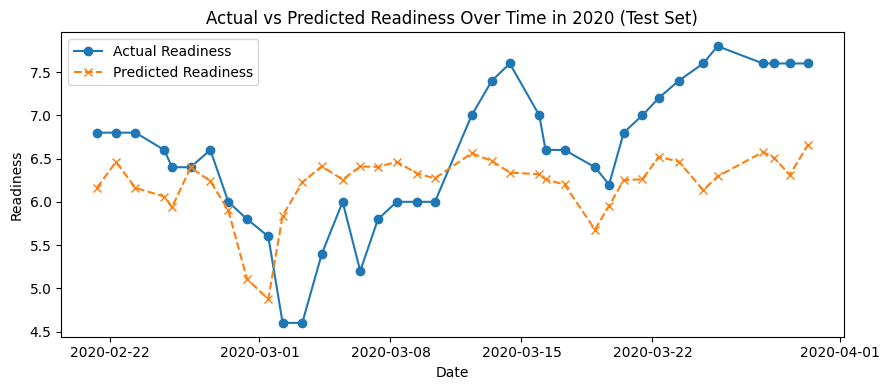

In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

df = pd.read_csv('wellness.csv')

# Convert timestamp to date and sort
df["effective_time_frame"] = pd.to_datetime(df["effective_time_frame"])
df = df.sort_values("effective_time_frame").reset_index(drop=True)

# drop rows w/ missing values
df = df.dropna()

# AHP Weights
W_SLEEP_DURATION = 0.30
W_SLEEP_QUALITY = 0.25
W_FATIGUE = 0.20
W_STRESS = 0.15
W_MOOD = 0.10

df["wellness_score"] = (
    W_SLEEP_DURATION * df["sleep_duration_h"] +
    W_SLEEP_QUALITY * df["sleep_quality"] +
    W_FATIGUE * (5 - df["fatigue"]) +   # invert fatigue (less fatigue = better)
    W_STRESS * (5 - df["stress"]) +    # invert stress
    W_MOOD * df["mood"]
)

# dates for x-axis
dates = df["effective_time_frame"].reset_index(drop=True)

# smoothing
df["readiness_smooth"] = df["readiness"].rolling(window=5).mean()

# target goal: predict readiness
X_raw = df[["wellness_score"]].values.astype("float32")
y_raw = df[["readiness_smooth"]].values.astype("float32")

# train size = 70% , test size = 30%
train_size = int(len(X_raw) * 0.7)

X_train_raw = X_raw[:train_size]
X_test_raw = X_raw[train_size:]
y_train_raw = y_raw[:train_size]
y_test_raw = y_raw[train_size:]

# scale stuff (0-1) for lighter training
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train_raw)
X_test = scaler_X.transform(X_test_raw)

y_train = scaler_y.fit_transform(y_train_raw)
y_test = scaler_y.transform(y_test_raw)

# supervised learning for n-1 (lookback = 5 days before)
def create_dataset(X, y, look_back=5):
  Xs, ys = [], []
  for i in range(len(X) - look_back):
    Xs.append(X[i:i + look_back, 0])
    ys.append(y[i + look_back, 0])
  return np.array(Xs), np.array(ys)

look_back = 5
trainX, trainY = create_dataset(X_train, y_train, look_back)
testX, testY = create_dataset(X_test, y_test, look_back)

# XGBoost model
model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    objective='reg:squarederror',
    random_state=42
)

model.fit(trainX, trainY)

# predict
pred = model.predict(testX)
pred = scaler_y.inverse_transform(pred.reshape(-1, 1))
testY = scaler_y.inverse_transform(testY.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(testY, pred))
print(f"Test RMSE (Readiness Prediction): {rmse:.2f}")


test_start_idx = train_size
test_dates = dates[test_start_idx + look_back : test_start_idx + look_back + len(pred)]

plt.figure(figsize=(9, 4))

plt.plot(test_dates, testY, label="Actual Readiness", marker="o")
plt.plot(test_dates, pred, label="Predicted Readiness", linestyle="--", marker="x")

plt.title("Actual vs Predicted Readiness Over Time in 2020 (Test Set)")
plt.xlabel("Date")
plt.ylabel("Readiness")
plt.legend()
plt.tight_layout()
plt.show()
